# 11 squares in a square, by cutting the corners off and growing them back

In [1]:
import os
import sys

# The modules live at the repo root, but a Jupyter kernel starts in the notebook's OWN directory, so
# walk up until model.py is in sight. Works whether this is opened from tests/ or from the root.
root = os.getcwd()
while not os.path.isfile(os.path.join(root, "model.py")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)

import time

import numpy as np
from matplotlib import pyplot as plt

import records
import roundedGeometry as rg
from model import Model

## 1. Parameters

`q = rho / maxRho` is the working variable rather than `rho` itself: it is dimensionless, it is capped
at 1 by construction (`maxRho` is half the edge at a square), and it **follows the backbone through a
density change automatically**, which a stored absolute radius would not.

In [2]:
N = 26                     # squares
exactArcs = True           # THE CORNER IS AN ARC. Every distance, crossing and integral is taken
                           # against the true circle -- roundedContact.py -- so there is no chording
                           # error at all. numpy only, so it costs about 9x the chorded path at
                           # N = 11 (0.30 s per force evaluation against 0.034); the CUDA port is
                           # what makes it affordable at N = 26
qStart = 0.85              # starting roundness, as a fraction of the disk limit
qSpread = 0.60             # spread of log q -- the width the corners get to trade across
qEnd = 0.02                # where the roundness schedule finishes before the sharp handover
qCap = 0.995               # strictly inside the disk limit: at exactly 1 the straight runs vanish
excessStart = 1e-6         # load at the ROUND end, where the corners can absorb it
excessEnd = 3e-8           # load at the SHARP handover. 1e-6 there held phi at 0.766, +4.6%
                           # over the record -- far off the jamming manifold (see sec 7)
scheduleSteps = 100         # rungs taking q to monodisperse zero
roundnessExponent = 2.0    # >1 makes the ramp SLOW at the start and fast at the end (see sec 7)
roundedOverjam = 1.10      # start the ROUNDED area this far ABOVE the best-known density. It is a
                           # multiple of the record rather than an absolute number BECAUSE THE WHOLE
                           # METHOD NEEDS THE SCHEDULE TO COME DOWN ONTO THE ANSWER: a run that starts
                           # below the target has already given away the thing the load was for, and
                           # phi(record) ranges from 0.73 at N = 11 to 0.82 at N = 26
seed = 420

WALL = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 1.0], [1.0, 0.0]])   # clockwise: a container

print(records.describe(N))
print(f"target phi = {records.maximumDensity(N):.6f}")

n = 26: best known (not proved) is side 5.62132034 = 7/2 + 3 sqrt(2)/2
target phi = 0.822805


## 2. The corner-cut formalism

Cam's own notation, from `notes/roundedDefinitions.tex`:

    t_i   = rho_i / tan(theta_i / 2)                       kiss offset along each incident edge
    a-_i  = v_i - t_i eInHat,   a+_i = v_i + t_i eOutHat   kiss points
    z_i   = v_i + (rho_i / sin(theta_i / 2)) bHat          circle centre
    psi_i = pi - theta_i                                   arc sweep

Each corner removes a kite minus a wedge, `rho t - rho^2 psi / 2`. At a right angle that is
`rho^2 (4 - pi) / 4`, so a square of side `L` with four equal radii keeps a fraction
`1 - (4 - pi) q^2 / 4` of its area — `pi/4` at `q = 1`, which is the disk. Checked against the
shoelace of the chorded loop below.

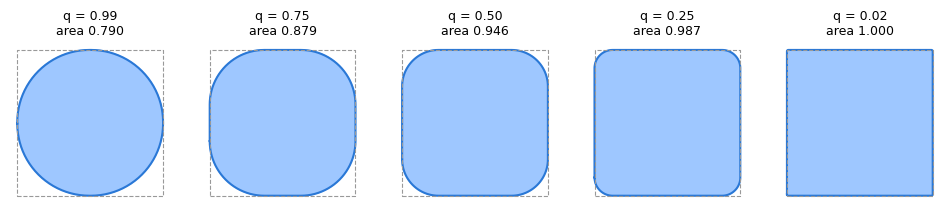

     q     analytic   chorded (4000)    1-(4-pi)q^2/4
  0.99   0.78966874       0.78966872       0.78966874
  0.50   0.94634954       0.94634954       0.94634954
  0.10   0.99785398       0.99785398       0.99785398


In [3]:
square = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]])
prv, nxt = np.roll(np.arange(4), 1), np.roll(np.arange(4), -1)
sign = rg.convexSign(square, prv, nxt)

figure, axes = plt.subplots(1, 5, figsize = (12, 2.4))
for axis, q in zip(axes, [0.99, 0.75, 0.5, 0.25, 0.02]):
    rho = np.full(4, q * 0.5)
    loop = rg.roundedPositions(square, prv, nxt, rho, sign, 24).reshape(-1, 2)
    closed = np.vstack([loop, loop[:1]])
    axis.fill(closed[:, 0], closed[:, 1], color = "#9ec7ff")
    axis.plot(closed[:, 0], closed[:, 1], color = "#2a78d6", lw = 1.5)
    axis.plot(*square[[0,1,2,3,0]].T, color = "0.6", lw = 0.8, ls = "--")
    kept = 1.0 - (4.0 - np.pi) * q ** 2 / 4.0
    axis.set_title(f"q = {q:.2f}\narea {kept:.3f}", fontsize = 9)
    axis.set_aspect("equal"); axis.axis("off")
plt.show()

def shoelace(loop):
    f = np.roll(loop, -1, axis = 0)
    return 0.5 * float(np.sum(loop[:, 0] * f[:, 1] - f[:, 0] * loop[:, 1]))

print(f"{'q':>6} {'analytic':>12} {'chorded (4000)':>16} {'1-(4-pi)q^2/4':>16}")
for q in (0.99, 0.5, 0.1):
    rho = np.full(4, q * 0.5)
    fine = rg.roundedPositions(square, prv, nxt, rho, sign, 4000).reshape(-1, 2)
    analytic = 1.0 - rg.cornerAreaLoss(square, prv, nxt, rho).sum()
    print(f"{q:>6.2f} {analytic:>12.8f} {shoelace(fine):>16.8f} "
          f"{1.0 - (4.0 - np.pi) * q ** 2 / 4.0:>16.8f}")

## 3. Build: 11 squares with a fixed backbone

`setConstraints(area = True, edge = True)` makes each quadrilateral **rigid**: four edge lengths plus
the area is five conditions on eight coordinates, leaving exactly the three rigid-body motions. So the
backbone really is a square throughout, and nothing but `rho` can change the shape.

The backbone density starts well **above** the record ceiling, and that is correct rather than
infeasible: the backbone squares overlap, and the corners that would have collided have been cut away.
Only the rounded shape has to be disjoint. `checkDensityFeasible` compares against the sharp ceiling
and would object, so it is not consulted here.

Centres go on a lattice — the depth contact energy is non-monotonic past half overlap, so a stacked
pair is a genuine force-balanced minimum that relaxation walks *into*.

In [4]:
backbonePhi = 1.2
model = Model(N = N, n = 4, seed = seed)
model.generateEquilateralPolygons(phi = backbonePhi, kappa = 4.0)
model.setMonoPerimeter()
model.placeOnGrid()
model.addShape(WALL)
model.pinVertices(np.arange(model.getNumVertices())[-4:])
model.setBoundaryConditions("fixed")
model.setSpringConstants(area = 1.0, edge = 1.0, perimeter = 0.0)
model.setConstraints(area = True, edge = True)

active = slice(0, 4 * N)                     # the squares' vertices; the wall is never rounded
print(f"backbone phi {model.getPackingFraction():.5f}   shape index "
      f"{model.getShapeIndices()[:N].min():.6f}..{model.getShapeIndices()[:N].max():.6f}")

backbone phi 1.20000   shape index 4.000000..4.000000


/tmp/ipykernel_122937/4179125480.py:5: UserWarning: 
*** the polygons overhang a 6 x 5 lattice ***
    the widest spans 0.3043 against a cell of 0.1667, so neighbouring cells will overlap a little. That is usually harmless -- only a pair more than HALFWAY through each other is trapped -- but check getPairOverlapArea() before minimizing, and start at a lower packing fraction if it is a large fraction of a polygon's area.
  model.placeOnGrid()


## 4. Seed the radii, fix the rounded areas, and switch the geometry on

`log q`, the corner radii, is held to a **log-normal** by fixing the mean and variance of its log,
leaving the other `n-2` freedoms free — so one corner may stay round while another go  q 0.8518 +- 0.599   excess 1.00e-06 (target 9.94e-07, 1% off)   roundedPhi 0.82385   backbonePhi 0.99645

  q 0.8556 +- 0.596   excess 1.06e-06 (target 9.78e-07, 8% off)   roundedPhi 0.82385   backbonePhi 0.99775

  q 0.8576 +- 0.591   excess 9.57e-07 (target 9.51e-07, 1% off)   roundedPhi 0.82220   backbonePhi 0.99654

  q 0.8567 +- 0.585   excess 9.51e-07 (target 9.14e-07, 4% off)   roundedPhi 0.82220   backbonePhi 0.99643

es sharp. That
is a distribution rather than a set of per-corner targets, which is what lets corners *trade*.

**The area that is held fixed is the ROUNDED one, and it is monodisperse.** Every square is scaled so
the shape the contact law actually sees has area `roundedOverjam * maximumDensity(N) / N`, and it is put back there after
every change to `q`. Cutting a corner therefore no longer shrinks the polygon: the backbone inflates to
pay for the material the arc removes, and deflates again as the schedule takes `q` down.

That is the whole point of the change. Previously the *backbone* was the fixed thing, so the rounded
area grew back as `q` fell — the packing densified on its own while the schedule ran, and the density
controller in section 7 was left fighting a drift it had not asked for. Now the only thing that moves
the density is the load, which is what the controller is for.

At `q = 0` the two areas coincide, so the handover in section 8 is continuous in the quantity that
matters.

In [5]:
def applyRoundness(model, q):
    """rho = q * maxRho, per vertex. maxRho is half the edge at a square -- the disk limit."""
    model.setRho(np.clip(q, 1e-9, qCap) * model.getMaxRho())

def projectLogNormal(logQ, mean, spread):
    """Hold the two moments that define a log-normal, leaving the other n-2 freedoms to trade."""
    centred = logQ - logQ.mean()
    width = centred.std()
    return mean + (spread / width if width > 1e-12 else 1.0) * centred

def measuredAreas(model):
    """The areas of the shape the contact law is actually handed.

    Rounded under round geometry, the backbone itself under sharp -- so the same density knob works on
    both sides of the section 8 handover, and reads the same number at the moment of it."""
    if model.getGeometryType() == "round":
        return model.getRoundedAreas()[:N]
    return model.getAreas()[:N]

def roundedPhi(model):
    return float(measuredAreas(model).sum())

def scalePolygons(model, factors):
    """Scale each square about its OWN centroid and re-sync its targets, so it stays rigid at its new
    size. rho follows for free, because q is a fraction of maxRho and maxRho scales with the edge."""
    r = model.packing.positions.reshape(-1, 2)
    starts = model.packing.startIndices
    for p in range(N):
        block = slice(int(starts[p]), int(starts[p + 1]))
        centroid = r[block].mean(axis = 0)
        r[block] = centroid + factors[p] * (r[block] - centroid)
    model.syncTargetAreas()
    model.syncTargetPerimeters()
    model.packing._forces = None
    model._forces = model._energy = None

def holdMeasuredArea(model, q, area):
    """Scale every square until the shape the law sees has area `area`, then re-apply q.

    EXACT IN ONE STEP, not an iteration: with q held, rho = q * maxRho scales with the polygon, so the
    rounded area is homogeneous of degree two in the coordinates and sqrt(area / current) lands on it.

    This replaces setPackingFraction as the density knob. The two do the same mechanical thing -- scale
    each polygon about its own centroid, leaving the box alone -- but this one holds the area of the
    ROUNDED shape, which is the area that has to be conserved if cutting a corner is not to change how
    much material is in the box."""
    scalePolygons(model, np.sqrt(area / measuredAreas(model)))
    applyRoundness(model, q)

rng = np.random.default_rng(seed)
q = np.zeros(model.getNumVertices())
q[active] = np.clip(np.exp(projectLogNormal(rng.standard_normal(4 * N), np.log(qStart), qSpread)),
                    1e-9, qCap)
applyRoundness(model, q)
model.setGeometryType("round", exact = exactArcs)
holdMeasuredArea(model, q, roundedOverjam * records.maximumDensity(N) / N)

if exactArcs:
    print("contact law: EXACT ARCS (roundedContact) -- no chording error, numpy only")
else:
    vertexCount = int(np.diff(model.roundedPacking().startIndices).max())
    print(f"contact law: CHORDED, {vertexCount} vertices per body -- depth contact runs on "
          f"{'CUDA' if vertexCount <= 64 else 'NUMPY (over the 64-vertex kernel cap)'}")

areas = measuredAreas(model)
print(f"rounded areas equal to {areas.mean():.6f}, spread {areas.std() / areas.mean():.1e} "
      f"(monodisperse by construction)")
print(f"q in [{q[active].min():.3f}, {q[active].max():.3f}]   "
      f"backbone phi {model.getPackingFraction():.5f}   rounded phi {roundedPhi(model):.5f}")
print(f"predicted ratio 1-(4-pi)q^2/4 with q = exp(mean log q): "
      f"{1.0 - (4.0 - np.pi) * np.exp(np.log(q[active]).mean()) ** 2 / 4.0:.5f}")

contact law: EXACT ARCS (roundedContact) -- no chording error, numpy only
rounded areas equal to 0.034811, spread 8.1e-16 (monodisperse by construction)
q in [0.162, 0.995]   backbone phi 1.05387   rounded phi 0.90508
predicted ratio 1-(4-pi)q^2/4 with q = exp(mean log q): 0.88877


## 5. First minimization — `rho` fixed exactly, on the AREA tier

Untangle on the **overlap area** first. Overlap area is *maximal* at full stacking, so its gradient
always pushes a pair apart and there is no barrier to be caught behind. The depth law is the opposite:
penetration depth peaks near half overlap and falls to nothing at full stacking, so a stacked pair
sits in a genuine force-balanced minimum. Starting overjammed on the depth tier would be starting
inside that trap.

`rho` is held precisely here — this pass is about the arrangement, not the shape.

In [6]:
model.setModelType("area")
start = time.time()
steps = model.minimizeFIRE(maxUnbalancedForce = 1e-6, maxSteps = 2500, progressBar = True)
print(f"{steps} FIRE steps in {time.time() - start:.0f}s   max|F| "
      f"{model.getMaxUnbalancedForce():.2e}")
print(f"rounded overlap area {model.getOverlapArea():.3e}   "
      f"max|C| {np.abs(model.constraintResidual()).max():.1e}")
print(f"rounded phi {roundedPhi(model):.5f}")

/home/rdennis/Documents/Code/pyPolygon/model.py:3742: UserWarning: 
*** pyPolygon is falling back to the PYTHON (numpy) tier -- the library loaded but no usable GPU responded ***
    The GPU overlap is 150-650x faster; expect minimization to be very slow.
    A driver/library version mismatch after a driver update is the usual cause -- compare 'cat /proc/driver/nvidia/version' with the installed libcuda; a reboot normally clears it. If the device was only BUSY or the library was rebuilt under this process, the failure is transient: call cudaOverlap.resetAvailability() to probe again.
  useCuda = cudaOverlap.isAvailable()


FIRE (constrained):   0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
model.draw()
plt.show()

## 6. Second minimization — `rho` free, held only by its distribution, on the DEPTH tier

Two blocks, alternating: the vertices go to `minimizeLBFGS` with the backbone constraints live, then
the radii take a gradient step and are projected back onto the log-normal. Alternating rather than
joint because the vertex block already has a constrained minimizer that knows about SHAKE, and `rho`
has no constraint but its distribution.

The rounded area is restored after every `rho` step, so the radii are trading *shape* here and nothing
else — a corner that rounds more forces its own backbone to inflate, and pays for it in the
arrangement rather than in the area budget.

Watch the sign column. `dE/dq` is **negative** (so the reported `-dE/dq` is positive) — the packing
lowers its energy by rounding *more*. The projection is what stops it running away to the disk.

In [ ]:
model.setDepthContact(stiffness = 1.0, wallStiffness = 10.0)
mean, spread = np.log(qStart), qSpread
area = roundedOverjam * records.maximumDensity(N) / N
start = time.time()

for round in range(8):
    model.minimizeLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 600)
    model.calcForceEnergy()
    # Read the relaxed state BEFORE touching rho -- setRho drops the cached force and energy, so
    # anything printed after the update would be reporting None.
    energy, got, phi = model.getEnergy(), model.getExcessEnergy(), roundedPhi(model)
    gradient = -(model.getRhoForces() * model.getMaxRho())[active]      # dE/dq
    print(f"  round {round}: E {energy:.3e}  excess {got:.2e}  roundedPhi {phi:.5f}  "
          f"q {q[active].mean():.4f}  fraction of dE/dq < 0: {float(np.mean(gradient < 0)):.2f}")

    scale = max(np.abs(gradient * q[active]).max(), 1e-30)
    logQ = np.log(q[active]) - 0.5 * gradient * q[active] / scale
    q[active] = np.clip(np.exp(projectLogNormal(logQ, mean, spread)), 1e-9, qCap)
    applyRoundness(model, q)
    # THE ROUNDED AREA IS THE INVARIANT. A corner that just rounded further cut more material away, so
    # its backbone has to inflate to put that material back. Skipping this is what used to let the
    # radii shed load by quietly shrinking the shape -- which reads as a lower energy and is really a
    # decompression.
    holdMeasuredArea(model, q, area)
print(f"{time.time() - start:.0f}s")

In [ ]:
model.draw()
plt.show()

## 7. The schedule — `q` to zero, holding the load

Per rung: narrow the roundness distribution, lower it, restore the rounded area, re-establish the
excess energy, relax. The density is an **output** of that hold, never a control parameter.

**The load is ramped down too, and it has to be.** Holding `1e-6` all the way to the handover left the
packing at `phi = 0.766` when it turned sharp — 4.6% above the best known 0.7318, so the squares were
nowhere near their jamming manifold and the arrangement was locked in before the decompression could
do anything. The excess now runs `excessStart -> excessEnd` on the same `progress` variable as the
roundness: loaded while the corners are round and can absorb it, nearly released by the time the shape
is a square.

**The ramp is slow at the start and fast at the end** (`roundnessExponent > 1`). Progress along
`log q` goes as `t ** roundnessExponent`, so the early rungs barely move the radii and the late ones
sweep through. That is the right way round: while the corners are still round they are the only thing
absorbing the load and the packing can genuinely rearrange, whereas once `rho` is small the contacts
are flat-on-flat and the arrangement is locked — spending rungs there buys nothing.

`Model.holdExcessEnergy` is not used, and the reason is specific: it moves density with
`setPackingFraction`, which holds the BACKBONE area — exactly the quantity we have stopped holding.
`holdMeasuredArea` is the same mechanical step written against the rounded area instead.

Watch the backbone density falling toward the rounded one as `q` shrinks — by the last rung they are
the same number, because the shape is the same shape. The rounded one now moves only when the load
controller moves it.

In [ ]:
def holdExcess(model, q, target, area, rounds = 60, tolerance = 0.10, maxStep = 1.01):
    """Two-sided: compress a loose packing, decompress an overjammed one, until the relaxed pair
    contact energy sits at `target`. The knob is the ROUNDED area per square, and it is returned so
    the caller keeps hold of where the controller left the density.

    PROPORTIONAL IN LOG, NOT A FIXED STEP. The excess is extremely stiff in the density, so a fixed 1%
    step in area is far wider than the 10% tolerance band on the energy: the controller crosses the
    band without ever landing in it and then oscillates until it runs out of rounds. Measured on the
    fixed-step version, EVERY rung of an N = 11 run exited on the round limit rather than on tolerance,
    between 25% and 72% below its target -- so the load being held was not the load the schedule asked
    for, which is the one thing this function exists to guarantee.

    The stiffness d log(excess) / d log(area) is measured from the last two rounds by secant and used
    to size the next one. The step is still capped at `maxStep`, so far from the target this behaves
    exactly as before and only the approach changes."""
    fallbackSlope, previous = 20.0, None
    for _ in range(rounds):
        model.minimizeLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 1000)
        got = model.getExcessEnergy()
        if got > 0.0 and abs(got - target) <= tolerance * target:
            break
        if got <= 0.0:
            # Nothing is touching, so there is no slope to measure -- compress at the cap.
            step, previous = maxStep, None
        else:
            slope = fallbackSlope
            if previous is not None and abs(np.log(area / previous[0])) > 1e-12:
                measured = np.log(got / previous[1]) / np.log(area / previous[0])
                slope = float(np.clip(measured, 2.0, 200.0))
            previous = (area, got)
            step = float(np.exp(np.clip(np.log(target / got) / slope,
                                        -np.log(maxStep), np.log(maxStep))))
        area *= step
        holdMeasuredArea(model, q, area)
    return model.getExcessEnergy(), area

history = []
start = time.time()
for rung in range(scheduleSteps + 1):
    # SLOW AT THE START, FAST AT THE END: progress along log q goes as t ** roundnessExponent.
    progress = (rung / scheduleSteps) ** roundnessExponent
    mean = np.log(qStart) + np.log(qEnd / qStart) * progress
    spread = qSpread * (1.0 - progress)
    q[active] = np.clip(np.exp(projectLogNormal(np.log(q[active]), mean, spread)), 1e-9, qCap)
    applyRoundness(model, q)
    # Un-cutting the corners hands material back, so the backbone shrinks to keep the rounded area
    # where the controller put it. This is the line that stops the schedule densifying on its own.
    holdMeasuredArea(model, q, area)
    # The load comes off on the SAME progress variable as the roundness, so the handover happens
    # near jamming rather than 4.6% above it.
    target = excessStart * (excessEnd / excessStart) ** progress
    got, area = holdExcess(model, q, target, area)
    # sideSpread is the BACKBONE polydispersity the rounding is paying for. It is an output, not a
    # control: holding the rounded areas equal makes the backbones unequal while q is alive, by
    # exactly the amount each square's own corners cut away. It has to reach zero, and this is what
    # says whether it did.
    sides = np.sqrt(model.getAreas()[:N])
    history.append({"q": float(q[active].mean()), "spread": float(spread),
                    "sideSpread": float((sides.max() - sides.min()) / sides.mean()),
                    "excess": got, "target": float(target), "roundedPhi": roundedPhi(model),
                    "backbonePhi": model.getPackingFraction()})
    print(f"  q {q[active].mean():.4f} +- {spread:.3f}   excess {got:.2e} "
          f"(target {target:.2e}, {abs(got - target) / target:.0%} off)   "
          f"roundedPhi {roundedPhi(model):.5f}   backbonePhi {model.getPackingFraction():.5f}")
    model.draw()
    plt.show()
print(f"{time.time() - start:.0f}s")

## 8. Replace the rounded polygons with actual squares

`q` is now small and monodisperse, so the arcs are a rounding error on the corner. Switching the
geometry to `sharp` takes the limit **exactly** — the backbone was always the state, so this is a
change of what the tier is handed, not a change of the configuration.

The area barely moves across the handover now: at `q = qEnd` the corners have given back all but
`(4 - pi) qEnd^2 / 4` of themselves, which is what `roundedPhi` and the backbone `phi` printing the
same number to four figures is showing.

In [ ]:
before = roundedPhi(model)
model.setGeometryType("sharp")
print(f"rounded phi {before:.6f}  ->  sharp phi {model.getPackingFraction():.6f}")
# THE ANSWER IS ONLY AN ANSWER IF THE SQUARES ARE EQUAL, and this is the number that says they are.
# Holding the ROUNDED areas monodisperse makes the BACKBONES polydisperse while q is alive -- a corner
# that rounds more needs a bigger backbone to pay for it -- but the last schedule rung takes the spread
# of log q to exactly zero, and equal q with equal rounded area forces equal backbones. Measured, it
# comes out at 1e-15, so no snapping-out step is needed: it is already machine-exact.
sides = np.sqrt(model.getAreas()[:N])
print(f"square sides {sides.min():.8f}..{sides.max():.8f}, spread "
      f"{(sides.max() - sides.min()) / sides.mean():.2e}")
model.calcForceEnergy()
print(f"on becoming sharp: excess {model.getExcessEnergy():.3e}   "
      f"overlap area {model.getOverlapArea():.3e}")

model.minimizeLBFGS(maxUnbalancedForce = 1e-10, maxSteps = 4000)
print(f"relaxed: max|F| {model.getMaxUnbalancedForce():.2e}   "
      f"excess {model.getExcessEnergy():.3e}   overlap {model.getOverlapArea():.3e}   "
      f"max|C| {np.abs(model.constraintResidual()).max():.1e}")
model.draw()
plt.show()

## 9. Decompress to exactly zero

Walk the excess down by decades, then take the last step on the **exact overlap area**, which needs no
tolerance: the contact energy is purely repulsive, its only zero-energy states are disjoint ones, and
the area reads exactly `0.000e+00` once the packing is valid.

Only this last number is an answer. Everything above it carries overlap.

In [ ]:
# Start BELOW the handover load, or the two-sided hold would compress again on its first rung.
for level in excessEnd * np.array([0.3, 0.1, 0.03, 0.01]):
    got, area = holdExcess(model, q, level, area, rounds = 40)
    print(f"  excess {got:.2e}   phi {model.getPackingFraction():.6f}   "
          f"side {1.0 / np.sqrt(model.getPackingFraction() / N):.6f}")

def isValid(model):
    """Squares disjoint from each other AND inside the box.

    Both are EXACT zeros for a valid packing -- the contact laws are purely repulsive, so their only
    zero-energy states are the valid ones and there is no tolerance to pick. Testing the overlap alone
    is not enough: a run can reach zero overlap while still leaking 1e-09 into the wall."""
    return model.getOverlapArea() == 0.0 and model.getWallPenetration() == 0.0

def settle(model, q, area):
    holdMeasuredArea(model, q, area)
    model.minimizeLBFGS(maxUnbalancedForce = 1e-11, maxSteps = 4000)

# BOUND EVERY SEARCH THAT TESTS FOR AN EXACT ZERO. Shrinking each square about its OWN centroid cannot
# rescue one whose centroid has ended up outside the box, so `while not isValid` is not guaranteed to
# terminate -- measured, one seed of three spun here for minutes while its siblings finished, and the
# only reason it was visible at all is that it never reached the draw calls below. 200 rungs of 0.995
# take the area to 37% of where it started, which is far past any real answer, so hitting the cap is a
# genuine failure and should say so rather than hang.
low, high = area, area
for _ in range(200):
    if isValid(model):
        break
    low *= 0.995
    settle(model, q, low)
else:
    raise RuntimeError(f"no valid packing down to area {low:.6e}: overlap "
                       f"{model.getOverlapArea():.3e}, wall {model.getWallPenetration():.3e}")
for _ in range(24):
    model.draw()
    plt.show()
    middle = 0.5 * (low + high)
    settle(model, q, middle)
    if isValid(model):
        low = middle
    else:
        high = middle
settle(model, q, low)
# The bisection's last accepted size is re-minimized here from a DIFFERENT starting point, so it can
# land just on the wrong side of validity -- measured, 3.5e-18 of overlap and 1.4e-09 of wall
# penetration on a run whose bisection had been clean. Back off until the state actually reported IS
# valid; anything else quotes a number the packing does not achieve.
#
# The step SQUARES each round rather than repeating, so it starts at a tenth of a basis point and still
# covers a factor of five within fifteen rounds. A fixed 0.9999 would need thousands of them, each
# paying for a four-thousand-step minimization.
backoff = 0.9999
for _ in range(40):
    if isValid(model):
        break
    low *= backoff
    backoff *= backoff
    settle(model, q, low)

side = 1.0 / np.sqrt(model.getPackingFraction() / N)
print(f"\n{records.describe(N, side)}")
print(f"overlap area {model.getOverlapArea():.3e}   wall penetration "
      f"{model.getWallPenetration():.2e}   max|C| {np.abs(model.constraintResidual()).max():.1e}")

In [ ]:
figure, axes = plt.subplots(1, 4, figsize = (18, 3.8))
x = np.arange(len(history))

axes[0].plot(x, [h["q"] for h in history], marker = "o", color = "#2a78d6", label = "mean q")
axes[0].plot(x, [h["spread"] for h in history], marker = ".", color = "#eb6834",
             label = "spread of log q")
axes[0].plot(x, [h["sideSpread"] for h in history], marker = ".", color = "#1baf7a",
             label = "backbone side spread")
axes[0].set_ylabel("roundness"); axes[0].legend(fontsize = 8)

axes[1].plot(x, [h["roundedPhi"] for h in history], marker = "o", color = "#2a78d6",
             label = "rounded")
axes[1].plot(x, [h["backbonePhi"] for h in history], marker = ".", color = "0.5",
             label = "backbone")
axes[1].axhline(records.maximumDensity(N), ls = "--", color = "#eb6834", label = "best known")
axes[1].set_ylabel("packing fraction"); axes[1].legend(fontsize = 8)

axes[2].plot(x, [h["excess"] for h in history], marker = "o", color = "#2a78d6")
axes[2].plot(x, [h["target"] for h in history], ls = "--", color = "0.5", label = "target")
axes[2].legend(fontsize = 8)
axes[2].set_yscale("log"); axes[2].set_ylabel("excess energy (held)")

for axis in axes[:3]:
    axis.set_xlabel("schedule rung"); axis.grid(alpha = 0.3)

model.draw(ax = axes[3])
axes[3].set_title(f"s = {side:.5f}", fontsize = 10)
plt.tight_layout(); plt.show()

In [ ]:
model.minimizeFIRE(maxSteps = 100, maxUnbalancedForce = 1e-12)

In [ ]:
model.setPackingFraction(0.83)

In [ ]:
model.minimizeLBFGS(maxSteps = 1000, maxUnbalancedForce = 1e-12, progressBar = True)

In [ ]:
model.save("test26")